# 2.4b — AdaBoost *from scratch* : booster des apprenants faibles en comité pondéré

Le notebook 2.4 a utilisé le gradient boosting comme une boîte noire : « corriger les résidus plutôt que voter ». Ce carnet ouvre cette boîte sur le membre le plus ancien de la famille, **AdaBoost** (Freund & Schapire, 1997), et le reconstruit entièrement à la main. L'idée tient en une phrase : si l'on ne dispose que d'apprenants *faibles* — un seuil sur une seule variable, à peine meilleur que le hasard —, on peut néanmoins en assembler un apprenant *fort* en entraînant chacun d'eux sur les **erreurs pondérées** du précédent, puis en les réunissant dans un comité à vote pondéré.

Deux choses seront rendues **visibles**, car elles sont le cœur de l'algorithme et restent invisibles quand on appelle une bibliothèque : les **poids des exemples**, qui montent sur les points difficiles tour après tour, et la **frontière en escalier** du comité, qui émerge de la superposition de demi-plans élémentaires.

In [1]:
# Configuration et imports pour le notebook 2.4b
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score

np.random.seed(42)
# Figures compactes pour l'affichage
plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["figure.dpi"] = 90

print("Configuration OK : 2.4b - AdaBoost from scratch")

Configuration OK : 2.4b - AdaBoost from scratch


### Auto-évaluation

In [2]:
# Dispositif d'auto-evaluation de la serie (module partage, issue #18207)
import pathlib
import sys

for _racine in (pathlib.Path.cwd(), *pathlib.Path.cwd().parents):
    if (_racine / "MyIA.AI.Notebooks").is_dir():
        sys.path.insert(0, str(_racine / "MyIA.AI.Notebooks" / "ML" / "DataScienceWithAgents"))
        break

from auto_evaluation import question  # noqa: E402

### Avant de commencer — question de diagnostic

In [3]:
question(
    "Un « apprenant faible » (weak learner), pour un problème de classification binaire, c'est...",
    choix=[
        "Un classifieur à peine meilleur que le hasard (erreur un peu en dessous de 0,5)",
        "Un classifieur qui se trompe environ une fois sur deux, ni mieux ni moins",
        "Un petit réseau de neurones à deux couches",
    ],
    bonne="A",
    explication="L'apprenant faible doit faire *un peu* mieux que le hasard, pas beaucoup mieux. Tout le programme d'AdaBoost est là : partir de cette marge dérisoire et la capitaliser tour après tour.",
    reponse=None,  # remplacez None par la lettre de votre choix
)

Vérification — Un « apprenant faible » (weak learner), pour un problème de classification binaire, c'est...

  A. Un classifieur à peine meilleur que le hasard (erreur un peu en dessous de 0,5)
  B. Un classifieur qui se trompe environ une fois sur deux, ni mieux ni moins
  C. Un petit réseau de neurones à deux couches

Réponse non donnée. Remplacez `reponse=None` par la lettre de votre choix dans cette cellule, puis ré-exécutez-la pour afficher la correction.


## 1. Pourquoi AdaBoost — le paradoxe de l'apprenant faible

La théorie de l'apprentissage PAC (Valiant, 1984) distingue l'**apprentissage fort** (erreur arbitrairement faible, avec probabilité arbitrairement grande) de l'**apprentissage faible** (erreur juste sous 0,5). Schapire (1990) démontre le résultat fondateur du boosting : toute classe d'hypothèses faiblement apprenable est en réalité fortement apprenable — la transformation constructive qui le prouve est précisément un boosting.

AdaBoost en est la forme la plus célèbre : un **comité séquentiel** où chaque nouvel apprenant faible est entraîné sur un jeu de données *repondéré*, qui pénalise les exemples que le comité courant classe mal. Reprenons le jeu de données du notebook 2.4 — le cancer du sein, 30 variables quantitatives — et posons d'abord les deux **baselines explicites** qu'AdaBoost devra dépasser : la classe majoritaire, puis le meilleur stump (un seul seuil sur une seule variable) entraîné classiquement.

In [4]:
# Chargement du jeu de donnees cancer du sein (classification binaire reelle)
cancer = load_breast_cancer()
X = cancer.data            # matrice (569, 30) : 30 variables quantitatives
y = cancer.target          # vecteur (569,) : 0 = malignant, 1 = benign
noms_features = cancer.feature_names

# Division entrainement / test (70% / 30%), identique au notebook 2.4
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Labels {-1, +1} : c'est le langage du comite (signe de la somme ponderee)
y_pm_train = 2 * y_train - 1
y_pm_test = 2 * y_test - 1

# Baseline 1 : la classe majoritaire (aucune variable utilisee)
baseline_majorite = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)

# Baseline 2 : un stump seul, entraîne sur l'erreur non ponderee (comme sklearn)
stump_seul = DecisionTreeClassifier(max_depth=1, random_state=42).fit(X_train, y_train)

acc_majorite = accuracy_score(y_test, baseline_majorite.predict(X_test))
acc_stump = accuracy_score(y_test, stump_seul.predict(X_test))

print(f"Baseline classe majoritaire : {acc_majorite:.3f}")
print(f"Baseline stump seul          : {acc_stump:.3f}")
print("References du notebook 2.4 (meme decoupage) : arbre profond 0.918, foret 0.936, gradient boosting 0.947")

Baseline classe majoritaire : 0.626
Baseline stump seul          : 0.912
References du notebook 2.4 (meme decoupage) : arbre profond 0.918, foret 0.936, gradient boosting 0.947


### Lecture : le plafond que le comité doit dépasser

La classe majoritaire (accuracy 0,626) donne le plancher : ne rien apprendre des variables. Le stump seul fait bien mieux (0,912) : *un* seuil sur *une* variable — une mesure de rayon — et déjà la quasi-totalité de ce qu'un arbre profond obtient (0,918 au notebook 2.4, même découpage). Toute la question du carnet devient : que gagne-t-on à en empiler cinquante, repondérés sur leurs erreurs ?

## 2. L'apprenant faible : le stump décisionnel pondéré

Un **stump** coupe l'espace en deux demi-plans : `variable j <= seuil ?`. Il a deux polarités possibles (prédire +1 à gauche ou à droite). Sa qualité se mesure par l'**erreur pondérée**

$$\varepsilon = \sum_{i=1}^{n} w_i \cdot \mathbb{1}[h(x_i) \neq y_i], \qquad \sum_i w_i = 1,$$

où $w_i$ est le poids de l'exemple $i$. Avec des poids uniformes ($w_i = 1/n$), on retrouve l'erreur usuelle du notebook 2.4. Mais la pondération est le **levier central d'AdaBoost** : c'est en déplaçant la masse des $w_i$ que l'on force le stump suivant à s'intéresser aux exemples que le comité courant rate. La recherche du meilleur stump est un balayage exhaustif : toutes les variables, tous les seuils intermédiaires entre valeurs observées, les deux polarités.

In [5]:
def stump_predict(stump, X):
    '''Prediction {-1, +1} d'un stump : x[feature] <= seuil -> sens, sinon -sens.'''
    cote_gauche = X[:, stump["feature"]] <= stump["seuil"]
    return np.where(cote_gauche, stump["sens"], -stump["sens"])


def meilleur_stump(X, y_pm, w):
    '''Cherche le stump (variable, seuil, polarite) de plus faible erreur ponderee.

    Parametres
    ----------
    X : array (n, p)
    y_pm : array (n,) labels dans {-1, +1}
    w : array (n,) poids positifs sommant a 1

    Retour
    ------
    dict : feature (indice), seuil, sens (+1/-1), erreur ponderee, predictions
    '''
    n, p = X.shape
    est_positif = y_pm > 0                       # cible booleenne (n,)
    meilleur = {"erreur": 1.0}
    for j in range(p):
        valeurs = np.unique(X[:, j])
        if valeurs.size < 2:
            continue
        seuils = (valeurs[:-1] + valeurs[1:]) / 2          # milieux entre valeurs distinctes
        a_gauche = X[:, [j]] <= seuils[np.newaxis, :]      # (n, s) : x_j <= seuil
        # Polarite +1 : erreur si (a_gauche et y=-1) ou (a droite et y=+1)
        err_plus = (a_gauche != est_positif[:, np.newaxis]).T @ w   # (s,)
        # Polarite -1 : l'inverse
        err_moins = (a_gauche == est_positif[:, np.newaxis]).T @ w  # (s,)
        i_plus, i_moins = int(np.argmin(err_plus)), int(np.argmin(err_moins))
        if err_plus[i_plus] < meilleur["erreur"]:
            meilleur = {"feature": j, "seuil": float(seuils[i_plus]), "sens": 1,
                        "erreur": float(err_plus[i_plus])}
        if err_moins[i_moins] < meilleur["erreur"]:
            meilleur = {"feature": j, "seuil": float(seuils[i_moins]), "sens": -1,
                        "erreur": float(err_moins[i_moins])}
    meilleur["predictions"] = stump_predict(meilleur, X)
    return meilleur

In [6]:
# Premier stump : poids uniformes w_i = 1/n (identique a l'erreur usuelle)
w_uniformes = np.full(X_train.shape[0], 1.0 / X_train.shape[0])
premier = meilleur_stump(X_train, y_pm_train, w_uniformes)

acc_premier = accuracy_score(y_train, (premier["predictions"] > 0).astype(int))
print(f"Stump retenu : variable = {noms_features[premier['feature']]}")
print(f"             seuil = {premier['seuil']:.3f}, polarite = {premier['sens']:+d}")
print(f"Erreur ponderee epsilon = {premier['erreur']:.3f}  (accuracy train {acc_premier:.3f})")

Stump retenu : variable = worst radius


             seuil = 16.795, polarite = +1
Erreur ponderee epsilon = 0.073  (accuracy train 0.927)


### Lecture du premier stump : une seule question, déjà mieux que le hasard

Une unique variable (`worst radius`), un unique seuil : l'erreur pondérée ε = 0,073 est *très* en dessous de 0,5 — sur ce jeu, le meilleur stump est déjà bien plus qu'un apprenant faible, et c'est tant mieux : la théorie n'exige que ε < 0,5, elle n'interdit pas d'avoir de la marge. Notons la cohérence : sur des poids uniformes, l'erreur pondérée n'est autre que l'erreur d'entraînement usuelle, et le stump trouvé ici est le même objet que la baseline `DecisionTreeClassifier(max_depth=1)` ci-dessus. Tout ce qui suit consiste à faire varier les poids pour lui trouver des successeurs qui complètent, au lieu de répéter.

## 3. L'algorithme AdaBoost.SAMME — les poids en boucle

AdaBoost répète quatre lignes, tour après tour $t = 1, \dots, T$ :

1. **Apprendre** le stump $h_t$ de plus faible erreur pondérée $\varepsilon_t$ sur les poids $w^{(t)}$ courants ;
2. **Pondérer le stump** dans le comité : $\alpha_t = \tfrac{1}{2}\ln\frac{1-\varepsilon_t}{\varepsilon_t}$ — un stump fiable (petit $\varepsilon_t$) reçoit un gros vote, un stump à peine utile ($\varepsilon_t \to 0{,}5$) un vote nul ; si $\varepsilon_t \geq 0{,}5$ l'algorithme s'arrête (le stump serait contre-productif) ;
3. **Repondérer les exemples** : $w_i \leftarrow w_i \exp(-\alpha_t\, h_t(x_i)\, y_i)$ — les exemples *mal* classés voient leur poids monter de $e^{+\alpha_t}$, les bien classés descendre de $e^{-\alpha_t}$ ;
4. **Renormaliser** : $w \leftarrow w / \sum_i w_i$.

La théorie offre une garantie remarquable : l'erreur d'entraînement du comité final $H(x) = \mathrm{sign}\big(\sum_t \alpha_t h_t(x)\big)$ est **majorée par le produit des facteurs de normalisation**,

$$\mathrm{err}(H) \leq \prod_{t=1}^{T} Z_t = \prod_{t=1}^{T} 2\sqrt{\varepsilon_t (1 - \varepsilon_t)},$$

et chaque facteur est $< 1$ dès que $\varepsilon_t < 0{,}5$ : la borne décroît **géométriquement** avec $T$. C'est la version constructive du théorème de Schapire — on le vérifiera numériquement à l'Exercice 1.

In [7]:
def entrainer_adaboost(X, y_pm, T=50):
    '''Entrainement AdaBoost.SAMME : T stumps reponderee sur leurs erreurs.

    Retourne l'historique complet : stumps, votes alpha, erreurs, poids par tour.
    '''
    n = X.shape[0]
    w = np.full(n, 1.0 / n)                 # tour 0 : poids uniformes
    historique = {"stumps": [], "alphas": [], "erreurs": [], "poids": [w.copy()]}
    for t in range(T):
        stump = meilleur_stump(X, y_pm, w)
        eps = stump["erreur"]
        if eps <= 0.0 or eps >= 0.5:        # stump parfait ou inutile : on arrete
            print(f"Arret au tour {t + 1} : epsilon = {eps:.3f}")
            break
        alpha = 0.5 * np.log((1.0 - eps) / eps)
        # Les poids montent sur les erreurs (h*y = -1 -> exp(+alpha)), descendent ailleurs
        w = w * np.exp(-alpha * stump["predictions"] * y_pm)
        w = w / w.sum()                     # renormalisation Z_t
        historique["stumps"].append(stump)
        historique["alphas"].append(alpha)
        historique["erreurs"].append(eps)
        historique["poids"].append(w.copy())
    return historique


def predire_comite(historique, X):
    '''Prediction du comite (labels 0/1) : signe de la somme des votes ponderes.'''
    scores = np.zeros(X.shape[0])
    for alpha, stump in zip(historique["alphas"], historique["stumps"]):
        scores = scores + alpha * stump_predict(stump, X)
    return np.where(scores >= 0, 1, 0)

In [8]:
# Entrainement du comite : 50 stumps reponderees sur les memes donnees que 2.4
historique = entrainer_adaboost(X_train, y_pm_train, T=50)
T_effectif = len(historique["alphas"])

acc_train_comite = accuracy_score(y_train, predire_comite(historique, X_train))
acc_test_comite = accuracy_score(y_test, predire_comite(historique, X_test))

print(f"Comite de {T_effectif} stumps")
print(f"Accuracy train : {acc_train_comite:.3f}")
print(f"Accuracy test  : {acc_test_comite:.3f}")
print(f"A comparer : majoritaire {acc_majorite:.3f} | stump seul {acc_stump:.3f} | gradient boosting (2.4) 0.947")

Comite de 50 stumps
Accuracy train : 1.000
Accuracy test  : 0.959
A comparer : majoritaire 0.626 | stump seul 0.912 | gradient boosting (2.4) 0.947


### Lecture : le comité a transformé la marge dérisoire en avantage net

Avec les mêmes données et le même découpage que le notebook 2.4, le comité atteint 0,959 en test — devant la forêt aléatoire (0,936) et le gradient boosting (0,947) — alors que son accuracy d'entraînement est déjà parfaite (1,000). Cinquante seuils à une dimension, réunis par leurs votes pondérés, font mieux que chacun d'eux : exactement le scénario du théorème de Schapire. Le fait suivant prépare la question de transfert : l'erreur d'entraînement nulle n'entraîne pas d'effondrement en test — le comité continue d'apprendre des marges après avoir atteint zéro erreur. Le détail de la mécanique interne se joue dans les poids, que la section suivante rend visibles.

### Exercice 1 : la borne théorique vs l'erreur empirique

La borne $\mathrm{err}(H) \leq \prod_t 2\sqrt{\varepsilon_t(1-\varepsilon_t)}$ promet une décroissance géométrique. **Objectif** : la calculer à partir de `historique["erreurs"]`, la comparer à l'erreur d'entraînement *effective* du comité, et vérifier que la théorie est respectée.

**Indice** : `np.prod` effectue le produit d'un tableau ; la borne se calcule en une expression sur `2 * np.sqrt(erreurs_t * (1 - erreurs_t))`. Pour l'erreur empirique, `predire_comite(historique, X_train)` donne les prévisions (0/1) à comparer à `y_train`.

In [9]:
# Exercice 1 : borne theorique vs erreur d'entrainement effective du comite
erreurs_t = np.array(historique["erreurs"])

# TODO etudiant : produit des 2*sqrt(eps_t*(1-eps_t)) sur tous les tours
borne = None  # TODO etudiant : remplacer (np.prod sur 2 * np.sqrt(erreurs_t * (1 - erreurs_t)))

# TODO etudiant : fraction des exemples d'entrainement mal classes par le comite
erreur_train = None  # TODO etudiant : remplacer (moyenne de predire_comite(...) != y_train)

print(f"Exercice 1 a completer : borne = {borne}, erreur train = {erreur_train}")

Exercice 1 a completer : borne = None, erreur train = None


### Vérification 1 — lire une borne

In [10]:
question(
    "L'erreur effective du comité est très en dessous de la borne ∏ 2√(ε(1−ε)). Que faut-il en conclure ?",
    choix=[
        "La borne est valide mais pas serrée : elle majore l'erreur sans la prédire exactement",
        "La borne est fausse, il faut corriger l'algorithme",
        "Rien : une borne et une valeur ne se comparent pas",
    ],
    bonne="A",
    explication="La borne théorique est une garantie de décroissance, pas une égalité : le produit ∏ 2√(ε(1−ε)) majore l'erreur du comité. La trouver respectée — et souvent largement — est le comportement attendu.",
    reponse=None,  # remplacez None par la lettre de votre choix
)

Vérification — L'erreur effective du comité est très en dessous de la borne ∏ 2√(ε(1−ε)). Que faut-il en conclure ?

  A. La borne est valide mais pas serrée : elle majore l'erreur sans la prédire exactement
  B. La borne est fausse, il faut corriger l'algorithme
  C. Rien : une borne et une valeur ne se comparent pas

Réponse non donnée. Remplacez `reponse=None` par la lettre de votre choix dans cette cellule, puis ré-exécutez-la pour afficher la correction.


## 4. Les poids en action (concept-phare)

C'est ici qu'AdaBoost devient *visible*. À chaque tour, les exemples mal classés par le stump courant voient leur poids multiplié par $e^{+\alpha_t}$ (plus de 1) et les bien classés par $e^{-\alpha_t}$ (moins de 1) : la masse se concentre progressivement sur les exemples que le comité peine à classer, et le stump suivant est choisi pour eux. Le tableau ci-dessous montre la trajectoire $(\varepsilon_t, \alpha_t)$. Sur la figure, la **taille de chaque point suit son multiplicateur de poids par rapport à l'uniforme** ($w_i \cdot n$, l'aire $\propto$ multiplicateur : 1 = poids uniforme) et chaque panneau affiche la **part du poids total détenue par les 10 exemples les plus lourds** : les points faciles rétrécissent, les exemples difficiles gonflent, la part du top-10 monte.

 tour  epsilon_t  alpha_t
    1      0.073    1.272
    2      0.104    1.076
    3      0.147    0.878
    4      0.229    0.608
    5      0.256    0.534
    6      0.240    0.577
    7      0.265    0.511
    8      0.263    0.516
    9      0.258    0.528
   10      0.238    0.581
... (comite de 50 stumps au total)


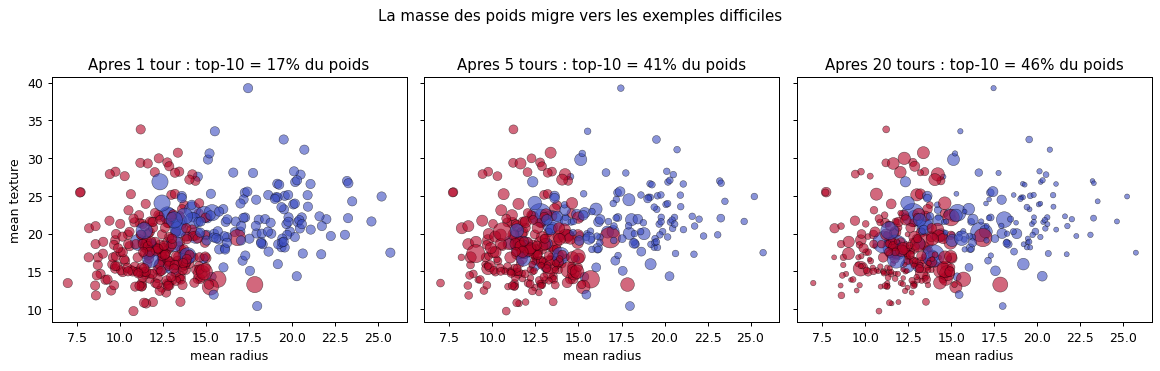

In [11]:
# Trajectoire des dix premiers tours : erreur ponderee et vote du stump
tableau_tours = pd.DataFrame({
    "tour": np.arange(1, len(historique["erreurs"]) + 1),
    "epsilon_t": np.round(historique["erreurs"], 3),
    "alpha_t": np.round(historique["alphas"], 3),
})
print(tableau_tours.head(10).to_string(index=False))
print(f"... (comite de {T_effectif} stumps au total)")

# Les poids sur le nuage 2D : aire proportionnelle au multiplicateur w_i * n (1 = uniforme)
n_train = X_train.shape[0]
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharex=True, sharey=True)
for ax, tour in zip(axes, (1, 5, 20)):
    poids_t = historique["poids"][tour]
    multiplicateur = poids_t * n_train                     # 1 = poids uniforme
    part_top10 = float(np.sort(poids_t)[::-1][:10].sum())  # masse des 10 plus lourds
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap="coolwarm",
               s=12 + 60 * np.sqrt(multiplicateur), alpha=0.6,
               edgecolors="k", linewidths=0.4)
    ax.set_title(f"Apres {tour} tour{'s' if tour > 1 else ''} : top-10 = {part_top10:.0%} du poids")
    ax.set_xlabel(noms_features[0])
axes[0].set_ylabel(noms_features[1])
fig.suptitle("La masse des poids migre vers les exemples difficiles", y=1.02)
plt.tight_layout()
plt.show()

### Lecture des poids : les exemples difficiles grossissent

La migration se lit dans les deux sens à la fois : les dix exemples les plus lourds détiennent 17 % de la masse au tour 1, 41 % au tour 5, 46 % au tour 20 — pendant que l'exemple médian descend vers 8 % de son poids uniforme (multiplicateur 0,08 au tour 20). Les points qui gonflent sont ceux que même un comité de plusieurs stumps classe mal — frontière de classes, valeurs atypiques. Deux conséquences se lisent aussi dans le tableau : l'erreur pondérée ε_t ne s'effondre pas — partie de 0,073 au premier tour, elle remonte en quelques tours vers 0,23-0,27 et y reste, parce que la repondération rend chaque tour *aussi difficile* que le précédent — et le vote α_t suit ε_t à la baisse (de 1,27 à environ 0,5) : un stump qui n'apprend qu'une marge dérisoire sur des poids concentrés pèse peu dans le comité final. AdaBoost n'élimine pas les exemples difficiles : il les facture.

### Exercice 2 : les exemples les plus pénalisés

**Objectif** : mesurer combien de fois le poids de chaque exemple a été multiplié entre le tour 0 (uniforme) et le comité final, puis identifier les 3 exemples au rapport final/initial le plus élevé.

**Indice** : `w_final / w_initial` donne le rapport pour chaque exemple ; `np.argsort(rapports)[-3:]` renvoie les indices des trois plus grands.

In [12]:
# Exercice 2 : les exemples dont le poids a le plus monte
w_initial = historique["poids"][0]
w_final = historique["poids"][-1]

# TODO etudiant : rapport final / initial pour chaque exemple
rapports = None  # TODO etudiant : remplacer (w_final / w_initial)

# TODO etudiant : indices des 3 plus grands rapports
top3 = None  # TODO etudiant : remplacer (np.argsort(rapports)[-3:])

print(f"Exercice 2 a completer : 3 exemples les plus penalises = {top3}")

Exercice 2 a completer : 3 exemples les plus penalises = None


### Vérification 2 — ce que dit un poids qui monte

In [13]:
question(
    "Le poids d'un exemple a été multiplié par plus de 100 sur le comité final. Cela signifie que...",
    choix=[
        "Les stumps successifs, à votes non négligeables, l'ont régulièrement mal classé : le comité le trouve difficile",
        "Cet exemple est sûrement une donnée corrompue qu'il faut supprimer",
        "Le poids monte au hasard : cette quantité ne s'interprète pas",
    ],
    bonne="A",
    explication="La montée est le produit des facteurs exp(+α_t) accumulés sur les tours où l'exemple est mal classé. Un rapport élevé signale un exemple réellement difficile pour la famille des stumps — c'est de l'information sur le jeu de données, pas un défaut de l'algorithme.",
    reponse=None,  # remplacez None par la lettre de votre choix
)

Vérification — Le poids d'un exemple a été multiplié par plus de 100 sur le comité final. Cela signifie que...

  A. Les stumps successifs, à votes non négligeables, l'ont régulièrement mal classé : le comité le trouve difficile
  B. Cet exemple est sûrement une donnée corrompue qu'il faut supprimer
  C. Le poids monte au hasard : cette quantité ne s'interprète pas

Réponse non donnée. Remplacez `reponse=None` par la lettre de votre choix dans cette cellule, puis ré-exécutez-la pour afficher la correction.


## 5. La frontière de décision du comité (concept-phare)

Un stump trace un **demi-plan**. Un comité de stumps pondérés superpose des demi-plans à votes croissants : la frontière devient un **escalier**, dont chaque marche est le seuil d'un stump influent. Comme au notebook 2.4, on visualise sur les deux premières variables (le comité est réentraîné sur ces deux seules colonnes pour la visualisation) : à gauche le premier stump, à droite le comité complet.

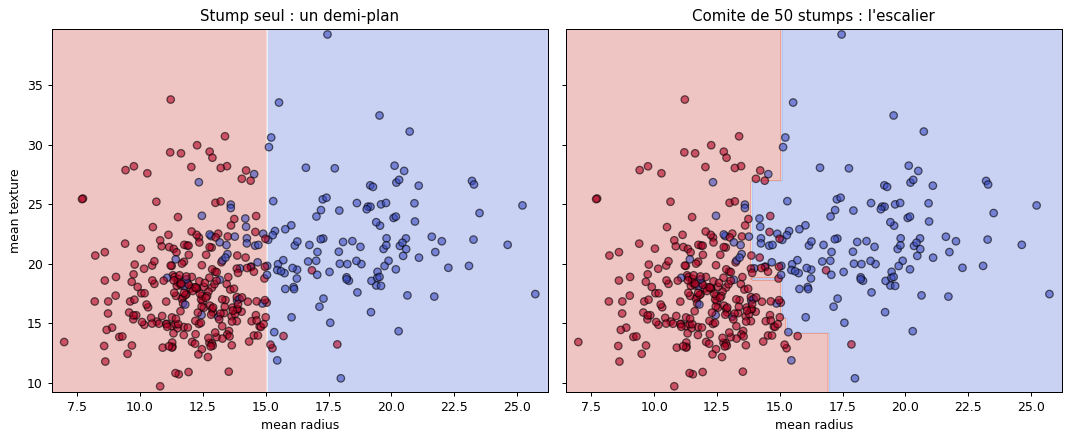

In [14]:
# Frontiere 2D : stump seul vs comite (reentraines sur les 2 premieres variables)
X2_train = X_train[:, [0, 1]]
historique_2d = entrainer_adaboost(X2_train, y_pm_train, T=50)

x_min, x_max = X2_train[:, 0].min() - 0.5, X2_train[:, 0].max() + 0.5
y_min, y_max = X2_train[:, 1].min() - 0.5, X2_train[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
grille = np.c_[xx.ravel(), yy.ravel()]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
# Gauche : le premier stump seul (demi-plan)
premier_2d = historique_2d["stumps"][0]
Z1 = (stump_predict(premier_2d, grille) > 0).astype(int).reshape(xx.shape)
axes[0].contourf(xx, yy, Z1, alpha=0.3, cmap="coolwarm")
axes[0].scatter(X2_train[:, 0], X2_train[:, 1], c=y_train, cmap="coolwarm",
                edgecolors="k", alpha=0.6)
axes[0].set_title("Stump seul : un demi-plan")
# Droite : le comite complet (superposition de demi-plans ponderee)
Z2 = predire_comite(historique_2d, grille).reshape(xx.shape)
axes[1].contourf(xx, yy, Z2, alpha=0.3, cmap="coolwarm")
axes[1].scatter(X2_train[:, 0], X2_train[:, 1], c=y_train, cmap="coolwarm",
                edgecolors="k", alpha=0.6)
axes[1].set_title(f"Comite de {len(historique_2d['alphas'])} stumps : l'escalier")
for ax in axes:
    ax.set_xlabel(noms_features[0])
axes[0].set_ylabel(noms_features[1])
plt.tight_layout()
plt.show()

### Lecture de la frontière : l'escalier du comité

Le demi-plan unique du stump gauche découpe le nuage en deux blocs — tout ce qu'un seuil sait faire. Le comité droit superpose cinquante de ces coupes, chacune ajustée aux erreurs pondérées des précédentes : la frontière se fragmente en marches qui épousent la zone d'interpénétration des deux classes, là où les exemples difficiles se concentrent. L'escalier est la signature géométrique du boosting discret : contrairement à la forêt du notebook 2.4, qui *lisse* en moyennant des arbres profonds, AdaBoost *affine* en empilant des coupes élémentaires orientées vers ses erreurs.

## 6. Comparaison avec scikit-learn

La classe `sklearn.ensemble.AdaBoostClassifier` implémente exactement l'algorithme SAMME reconstruit ci-dessus (depuis la version 1.6, SAMME est l'unique algorithme ; l'estimateur de base par défaut est le stump `DecisionTreeClassifier(max_depth=1)`). Deux implémentations indépendantes du même objet mathématique doivent converger : comparons accuracy de test et taux d'accord des prévisions.

In [15]:
# Comparaison : from scratch vs scikit-learn (meme T, meme random_state)
sklearn_adaboost = AdaBoostClassifier(n_estimators=50, random_state=42).fit(X_train, y_train)

acc_sklearn = accuracy_score(y_test, sklearn_adaboost.predict(X_test))
pred_scratch = predire_comite(historique, X_test)
accord = float(np.mean(sklearn_adaboost.predict(X_test) == pred_scratch))

print(f"AdaBoost from scratch : accuracy test = {acc_test_comite:.3f}")
print(f"AdaBoost sklearn      : accuracy test = {acc_sklearn:.3f}")
print(f"Taux d'accord des predictions de test : {accord:.3f}")

AdaBoost from scratch : accuracy test = 0.959
AdaBoost sklearn      : accuracy test = 0.959
Taux d'accord des predictions de test : 1.000


### Lecture : deux implémentations, un même algorithme

Les deux comités classent le jeu de test **à l'identique** : même accuracy (0,959), taux d'accord des prédictions de 1,000. L'implémentation à la main et la bibliothèque dérivent le même objet — mêmes stumps candidats, même règle de vote — et c'est le critère de validation attendu d'une réimplémentation *from scratch* : quand elle s'écarte de la référence, c'est le signe d'un bug dans l'une ou l'autre, pas d'une divergence de méthode.

### Exercice 3 : l'horizon T du comité

**Objectif** : mesurer l'accuracy de test du comité pour `T` dans `1, 2, 5, 10, 20, 50, 100`, puis identifier l'horizon le meilleur. On observera la vitesse de la montée initiale — la décroissance géométrique de la borne de l'Exercice 1 — et le plateau qui suit.

**Indice** : pour chaque `T`, `entrainer_adaboost(X_train, y_pm_train, T=T)` puis `accuracy_score(y_test, predire_comite(hist, X_test))` ; stocker dans une liste puis `horizons[np.argmax(acc_horizons)]`.

In [16]:
# Exercice 3 : l'effet du nombre de tours T sur l'accuracy de test
horizons = [1, 2, 5, 10, 20, 50, 100]

# TODO etudiant : entrainer un comite pour chaque T et mesurer son accuracy de test
acc_horizons = None  # TODO etudiant : remplacer (liste des accuracies de test)

# TODO etudiant : horizon qui maximise l'accuracy de test
meilleur_T = None  # TODO etudiant : remplacer (horizons[np.argmax(acc_horizons)])

print(f"Exercice 3 a completer : meilleur horizon = {meilleur_T}")

Exercice 3 a completer : meilleur horizon = None


### Vérification 3 — le rôle de T

In [17]:
question(
    "Entre T = 1 et T = 10 l'accuracy grimpe vite, puis elle plafonne (voire oscille légèrement) jusqu'à T = 100. Pourquoi ?",
    choix=[
        "Les premiers tours corrigent les erreurs les plus systématiques ; ensuite les stumps s'ajustent à des exemples de plus en plus difficiles, au gain décroissant",
        "L'algorithme s'arrête d'apprendre après 10 tours par construction",
        "T n'a aucun effet : seul le premier stump compte",
    ],
    bonne="A",
    explication="Chaque tour cible la masse de poids courante : les premières corrections sont les plus rentables (erreurs systématiques), les suivantes traitent des cas de plus en plus singuliers. Le plateau est la traduction empirique des rendements décroissants — et la raison pour laquelle on borne T.",
    reponse=None,  # remplacez None par la lettre de votre choix,
)

Vérification — Entre T = 1 et T = 10 l'accuracy grimpe vite, puis elle plafonne (voire oscille légèrement) jusqu'à T = 100. Pourquoi ?

  A. Les premiers tours corrigent les erreurs les plus systématiques ; ensuite les stumps s'ajustent à des exemples de plus en plus difficiles, au gain décroissant
  B. L'algorithme s'arrête d'apprendre après 10 tours par construction
  C. T n'a aucun effet : seul le premier stump compte

Réponse non donnée. Remplacez `reponse=None` par la lettre de votre choix dans cette cellule, puis ré-exécutez-la pour afficher la correction.


### Après le parcours — question de transfert

In [18]:
question(
    "AdaBoost additionne des stumps (capacité quasi nulle) jusqu'à T = 100 sans exploser en surapprentissage, là où un arbre profond de capacité comparable surapprend. L'explication proposée par Schapire et al. (1998) est...",
    choix=[
        "L'analyse par les marges : ajouter des tours augmente la marge minimale du comité sans augmenter la capacité des apprenants faibles",
        "AdaBoost contient une régularisation L2 cachée",
        "Les poids annulent la capacité du comité, qui reste un modèle simple",
    ],
    bonne="A",
    explication="L'argument des marges montre que le boosting continue d'augmenter la confiance de classification (la marge) bien après que l'erreur d'entraînement a atteint zéro — améliorer les marges améliore la généralisation sans accroître la capacité.",
    reponse=None,  # remplacez None par la lettre de votre choix,
)

Vérification — AdaBoost additionne des stumps (capacité quasi nulle) jusqu'à T = 100 sans exploser en surapprentissage, là où un arbre profond de capacité comparable surapprend. L'explication proposée par Schapire et al. (1998) est...

  A. L'analyse par les marges : ajouter des tours augmente la marge minimale du comité sans augmenter la capacité des apprenants faibles
  B. AdaBoost contient une régularisation L2 cachée
  C. Les poids annulent la capacité du comité, qui reste un modèle simple

Réponse non donnée. Remplacez `reponse=None` par la lettre de votre choix dans cette cellule, puis ré-exécutez-la pour afficher la correction.


## Conclusion et transition

Ce carnet a ouvert la boîte que le notebook 2.4 laissait fermée. Le gradient boosting y était présenté comme « corriger les résidus plutôt que voter » ; on voit maintenant les deux mécanismes de la même famille sous un jour complémentaire : **AdaBoost repondère les exemples** (les erreurs deviennent plus importantes) pendant que **le gradient boosting ajuste les cibles** (les résidus deviennent la nouvelle cible). Les deux empilent séquentiellement des apprenants faibles pour réduire le biais, et les deux s'arrêtent sur un horizon $T$ qui arbitre entre correction systématique et poursuite du bruit.

La boucle avec 2.4 est fermée ; la suite logique est le notebook 2.5 (biais-variance, validation croisée), qui donne le cadre commun où situer les deux : variance réduite par la forêt, biais réduit par le boosting.

## References

1. Schapire, R.E. (1990). *The Strength of Weak Learnability*. Machine Learning 5(2):197-227. — Le résultat fondateur : tout apprenant faible peut être transformé en apprenant fort.
2. Freund, Y. & Schapire, R.E. (1997). *A Decision-Theoretic Generalization of On-Line Learning and an Application to Boosting*. Journal of Computer and System Sciences 55(1):119-139. — AdaBoost : repondération des exemples et comité à vote pondéré.
3. Schapire, R.E., Freund, Y., Bartlett, P. & Lee, W.S. (1998). *Boosting the Margin: A New Explanation for the Effectiveness of Voting Methods*. Annals of Statistics 26(5):1651-1686. — L'analyse des marges : pourquoi le boosting résiste au surapprentissage.
4. Hastie, T., Tibshirani, R. & Friedman, J. (2009). *The Elements of Statistical Learning*. Springer (2e éd.), §§10.1-10.4. — Vue d'ensemble statistique du boosting.
5. Pedregosa, F. et al. (2011). *Scikit-learn: Machine Learning in Python*. Journal of Machine Learning Research 12:2825-2830. — `AdaBoostClassifier`, référence de la comparaison de la section 6.
6. Freund, Y. & Schapire, R.E. (2012). *Boosting: Foundations and Algorithms*. MIT Press. — Le livre de référence sur la théorie et la pratique du boosting.